In [33]:
# dependencies
import os
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition # this is the checker for the if you got a tool back
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from dotenv import load_dotenv
import requests

# Load environment variables from .env file
load_dotenv()

True

In [34]:
api_key = os.getenv("API_KEY")

llm = ChatGroq(model='deepseek-r1-distill-llama-70b',api_key=api_key)

In [35]:
# tools

@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

@tool
def substract(a: int, b: int) -> float:
    """substract a and b.

    Args:
        a: first int
        b: second int
    """
    return a-b 

@tool
def get_current_datetime() -> str:
    """Get the current date and time.
    
    Returns:
        A string containing the current date and time in format: YYYY-MM-DD HH:MM:SS
    """
    import datetime
    now = datetime.datetime.now()
    return now.strftime("%Y-%m-%d %H:%M:%S")

search = DuckDuckGoSearchRun()

In [36]:
# giving acces of tools to the llm 
tools = [add, multiply, divide, search, get_current_datetime]

llm_with_tools = llm.bind_tools(tools)

In [37]:
sys_msg = SystemMessage(content="""You are a helpful assistant tasked
                        - use search for currect info
                        - use tools for calculation""")

def reasoner(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

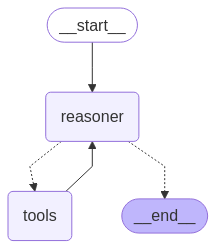

In [38]:
# Graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("reasoner", reasoner)
builder.add_node("tools", ToolNode(tools)) # for the tools

# Add edges
builder.add_edge(START, "reasoner")
builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

# Display the graph
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [39]:
messages = [HumanMessage(content="what is the first movie russel crowe won an oscar for")]
messages = react_graph.invoke({"messages": messages})

In [40]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the first movie russel crowe won an oscar for
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_6rcm)
 Call ID: call_6rcm
  Args:
    query: Russell Crowe first Oscar win movie
================================= Tool Message =================================
Name: duckduckgo_search

Russell Crowe (born April 7, 1964, Wellington, New Zealand) is a New Zealand-born Australian actor known for his commitment, intensity, and ruggedly handsome good looks.He won an Academy Award for Gladiator (2000).. At age four Crowe moved with his family to Australia.He was the son of film and television set caterers, and he made his acting debut at age six on Australian television in the ... Russell Crowe was nominated three consecutive years in the Best Actor category for "The Insider" (1999), "Gladiator" (2000) and "A Beautiful Mind" (2001). He won